In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import warnings
warnings.filterwarnings('ignore')

In [2]:
train = pd.read_csv(r"D:\Projects\Exoplanet-Detection\data\processed\train.csv")
val = pd.read_csv(r"D:\Projects\Exoplanet-Detection\data\processed\val.csv")
test = pd.read_csv(r"D:\Projects\Exoplanet-Detection\data\processed\test.csv")

print("Train shape:", train.shape)
print("Validation shape:", val.shape)
print("Test shape:", test.shape)

Train shape: (6830, 11)
Validation shape: (878, 11)
Test shape: (1464, 11)


In [3]:
X_train = train.drop('label', axis=1)
y_train = train['label']
X_val = val.drop('label', axis=1)
y_val = val['label']
X_test = test.drop('label', axis=1)
y_test = test['label']

print("Feature preparation complete")

Feature preparation complete


In [4]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = y_pred

    print(f"\n{'='*50}")
    print(model_name)
    print(f"{'='*50}")

    print("\nClassification Report:\n")
    print(
        classification_report(
            y_test,
            y_pred
        )
    )
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc
    }

print("Evaluation function ready")

Evaluation function ready


In [5]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train, y_train)

lr_results = evaluate_model(
    lr_model,
    X_test,
    y_test,
    "Logistic Regression"
)


Logistic Regression

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.76      0.84      1005
           1       0.63      0.87      0.73       459

    accuracy                           0.80      1464
   macro avg       0.78      0.82      0.78      1464
weighted avg       0.83      0.80      0.80      1464

Accuracy : 0.7964
Precision: 0.6256
Recall   : 0.8736
F1 Score : 0.7291
ROC-AUC  : 0.8824


In [6]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_results = evaluate_model(
    rf_model,
    X_test,
    y_test,
    "Random Forest"
)


Random Forest

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.91      0.93      1005
           1       0.83      0.90      0.86       459

    accuracy                           0.91      1464
   macro avg       0.89      0.91      0.90      1464
weighted avg       0.91      0.91      0.91      1464

Accuracy : 0.9105
Precision: 0.8267
Recall   : 0.9041
F1 Score : 0.8637
ROC-AUC  : 0.9717


In [8]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1,
    reg_lambda=2,
    min_child_weight=3,
    random_state=42,
    eval_metric='logloss')

xgb_model.fit(X_train, y_train)

xgb_results = evaluate_model(xgb_model, X_test, y_test, "Improved XGBoost")


Improved XGBoost

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.89      0.92      1005
           1       0.80      0.91      0.85       459

    accuracy                           0.90      1464
   macro avg       0.88      0.90      0.89      1464
weighted avg       0.91      0.90      0.90      1464

Accuracy : 0.8989
Precision: 0.7973
Recall   : 0.9085
F1 Score : 0.8493
ROC-AUC  : 0.9655


In [9]:
svm_model = SVC(
    kernel='rbf',
    probability=True,
    class_weight='balanced',
    random_state=42
)

svm_model.fit(X_train, y_train)

svm_results = evaluate_model(
    svm_model,
    X_test,
    y_test,
    "SVM"
)


SVM

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.78      0.86      1005
           1       0.65      0.92      0.76       459

    accuracy                           0.82      1464
   macro avg       0.80      0.85      0.81      1464
weighted avg       0.86      0.82      0.83      1464

Accuracy : 0.8224
Precision: 0.6547
Recall   : 0.9172
F1 Score : 0.7641
ROC-AUC  : 0.9196


In [10]:
results_df = pd.DataFrame([
    lr_results,
    rf_results,
    xgb_results,
    svm_results
])

results_df = results_df.round(4)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.7964,0.6256,0.8736,0.7291,0.8824
1,Random Forest,0.9105,0.8267,0.9041,0.8637,0.9717
2,Improved XGBoost,0.8989,0.7973,0.9085,0.8493,0.9655
3,SVM,0.8224,0.6547,0.9172,0.7641,0.9196


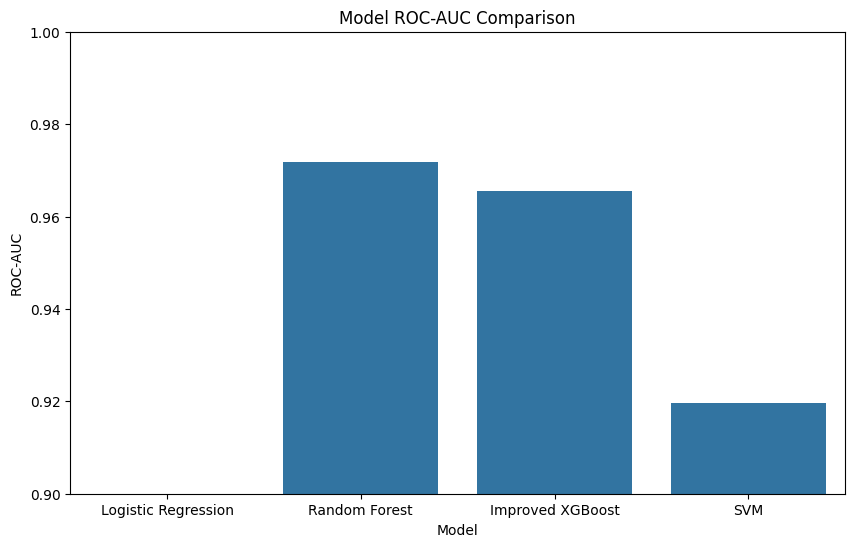

In [11]:
plt.figure(figsize=(10,6))
sns.barplot(
    x='Model',
    y='ROC-AUC',
    data=results_df
)

plt.title("Model ROC-AUC Comparison")
plt.ylim(0.9, 1.0)
plt.show()

In [12]:
import joblib

joblib.dump(lr_model,r"D:\Projects\Exoplanet-Detection\models\ml\logistic_regression.pkl")
joblib.dump(rf_model,r"D:\Projects\Exoplanet-Detection\models\ml\random_forest.pkl")
joblib.dump(xgb_model,r"D:\Projects\Exoplanet-Detection\models\ml\xgboost.pkl")
joblib.dump(svm_model,r"D:\Projects\Exoplanet-Detection\models\ml\svm.pkl")

print("All models saved successfully")

All models saved successfully


In [13]:
print("y_train distribution:")
print(y_train.value_counts())

print("\ny_test distribution:")
print(y_test.value_counts())

y_train distribution:
label
0    3415
1    3415
Name: count, dtype: int64

y_test distribution:
label
0    1005
1     459
Name: count, dtype: int64


In [14]:
sample = X_test.iloc[:10]
predictions = xgb_model.predict(sample)
probabilities = xgb_model.predict_proba(sample)
results = sample.copy()
results['Actual'] = y_test.iloc[:10].values
results['Predicted'] = predictions
results['Exoplanet_Probability'] = probabilities[:,1]
results

,koi_period,koi_prad,koi_depth,koi_duration,koi_impact,koi_insol,koi_teq,koi_steff,koi_srad,koi_model_snr,Actual,Predicted,Exoplanet_Probability
0,-0.403434,-0.015246,3.362662,0.755510,-0.026067,-0.069359,-0.385766,-0.208087,-0.131485,6.332498,0,0,0.039924
1,-0.467875,-0.037336,-0.321382,-0.579610,-0.027229,-0.053229,0.583555,0.387010,-0.067284,-0.340519,0,1,0.565981
2,-0.455593,-0.030507,0.468676,0.163395,-0.222115,-0.067761,-0.128810,-0.285600,-0.150425,0.041670,0,0,0.088083
3,2.598085,-0.036978,-0.320540,1.420188,0.015030,-0.070271,-0.932945,0.098213,-0.023307,-0.340519,0,0,0.227692
4,-0.350291,-0.036892,-0.319196,0.199639,-0.174192,-0.069222,-0.353647,-0.121823,-0.055568,-0.341203,1,1,0.819069
5,-0.210532,-0.036597,-0.318715,0.441672,0.052352,-0.069763,-0.505067,0.354505,-0.050592,-0.324442,1,1,0.866139
6,-0.472320,-0.037342,-0.320975,-0.095233,-0.105358,-0.060314,0.349541,0.021950,-0.136621,-0.345650,0,0,0.093334
7,-0.431831,-0.037150,-0.319001,-0.627304,-0.034490,-0.069416,-0.399532,-0.775681,-0.151869,-0.323986,1,1,0.874473
8,-0.452262,-0.036938,-0.318918,-0.254725,0.036959,-0.065759,0.054730,0.480776,-0.113188,-0.312470,1,1,0.837695
9,3.858127,-0.031805,-0.214434,-0.735646,0.069082,-0.070287,-1.020127,0.842085,-0.131967,-0.348272,0,0,0.072588
